<a href="https://colab.research.google.com/github/NataMaru/ML_for_people_tasks/blob/main/HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from process_bank_churn_new import preprocess_data
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings("ignore")
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,roc_curve, auc,f1_score,accuracy_score,confusion_matrix,root_mean_squared_error

In [2]:
raw_df = pd.read_csv('train.csv', index_col=0)
raw_df.head()


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
dataset= preprocess_data(raw_df)
X_train = dataset['X_train']
train_targets = dataset['train_targets']
X_val = dataset['X_val']
val_targets = dataset['val_targets']

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [4]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [5]:
# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model, inputs, targets, name=''):
    preds = model.predict(inputs)
    y_pred_proba = model.predict_proba(inputs)[:, 1]
    f1 = f1_score(targets, preds)
    print("F1 score: {:.2f}%".format(f1))
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.5f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

F1 score: 0.76%
Area under ROC score on Train dataset: 0.96097%


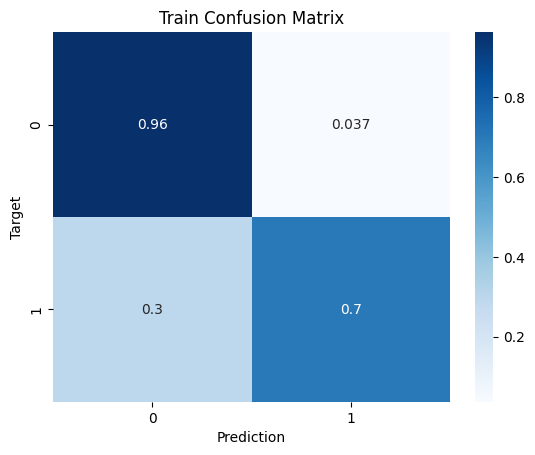

F1 score: 0.66%
Area under ROC score on Validation dataset: 0.87497%


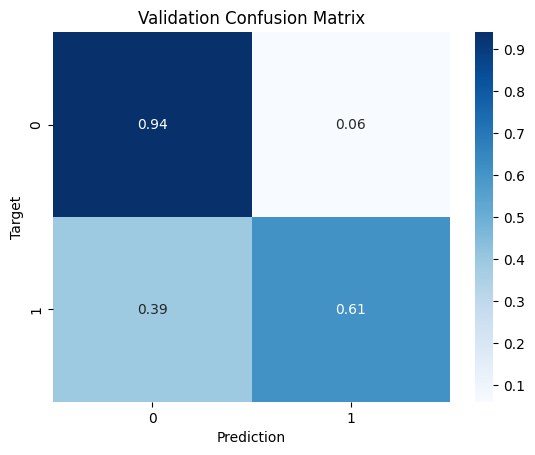

In [6]:
#Виведіть area under ROC для моделі на тренувальних і тестувальних даних.
train_preds = predict_and_plot(knn,X_train, train_targets, 'Train')
val_preds = predict_and_plot(knn,X_val, val_targets, 'Validation')

### висновок
1.  модель не є стабільною оскільки значення F1 на валідаційних даних дуже знизилось
2. модель перенавчилась на тренувальних даних і запам'ятала шум в даних і погано відпрацювала на валідаційних
3. високого зміщення модель не має

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [7]:
from sklearn.model_selection import GridSearchCV
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [8]:
knn_best = knn_gs.best_estimator_


F1 score: 0.72%
Area under ROC score on Train dataset: 0.94693%


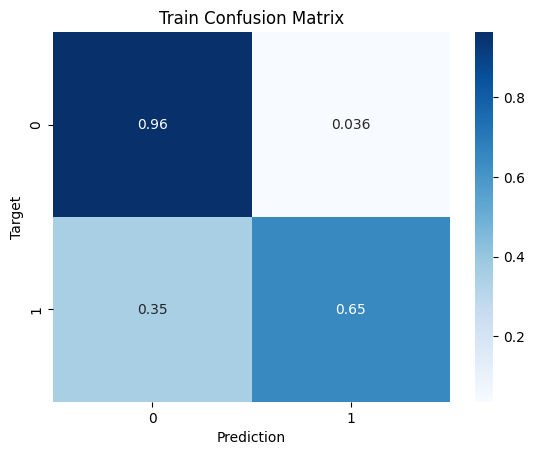

F1 score: 0.67%
Area under ROC score on Validation dataset: 0.90181%


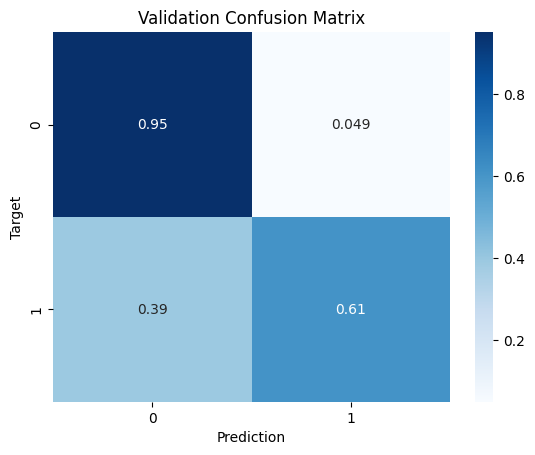

In [9]:
#Виведіть area under ROC для моделі на тренувальних і тестувальних даних.
train_preds = predict_and_plot(knn_best,X_train, train_targets, 'Train')
val_preds = predict_and_plot(knn_best,X_val, val_targets, 'Validation')

###висновки
модель покращилась і тепер на валідаційних даних також показує гарний результат.
також скоротився розрив між F1 на тренувальних і валідаційних даних

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [10]:

dt_base = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': np.arange(1, 21, 2),        # від 1 до 20 з кроком 2
    'max_leaf_nodes': np.arange(2, 11, 1)    # від 2 до 10 з кроком 1
}

grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=3,                 # крос-валідація на 3 фолди
    scoring='roc_auc'
)


grid_search_dt.fit(X_train, train_targets)


dt_best = grid_search_dt.best_estimator_


In [11]:
dt_best

DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=np.int64(10),
                       random_state=42)

F1 score: 0.67%
Area under ROC score on Train dataset: 0.90148%


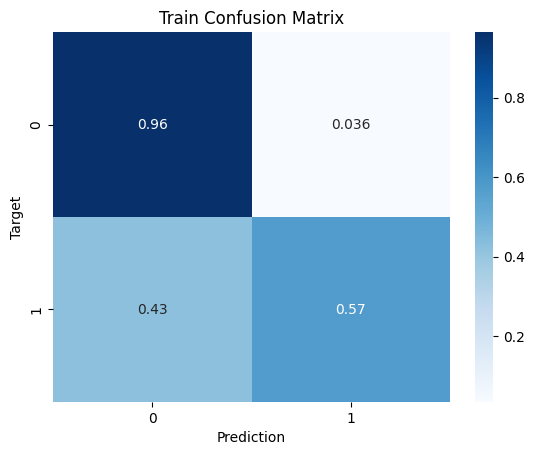

F1 score: 0.65%
Area under ROC score on Validation dataset: 0.90022%


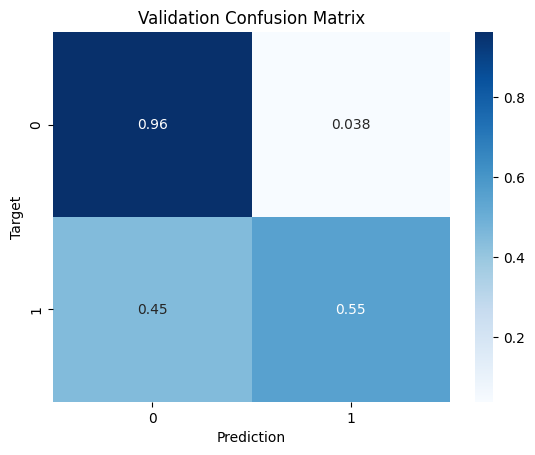

In [12]:
#Виведіть area under ROC для моделі на тренувальних і тестувальних даних.
train_preds = predict_and_plot(dt_best,X_train, train_targets, 'Train')
val_preds = predict_and_plot(dt_best,X_val, val_targets, 'Validation')

###висновок
модель не є кращою за ту, що була з обраними вручну параметрами в завданні по деревам прийняття рішень

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [13]:
from sklearn.model_selection import RandomizedSearchCV
param_distributions = {
    'max_depth': range(1, 21, 2),
    'max_leaf_nodes': range(2, 21, 1)
}
random_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=param_distributions,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    random_state=42
)

random_search.fit(X_train, train_targets)

# 5. Збереження результатів
dt_random_search_best = random_search.best_estimator_


In [14]:
dt_random_search_best

DecisionTreeClassifier(max_depth=7, max_leaf_nodes=20, random_state=42)

F1 score: 0.73%
Area under ROC score on Train dataset: 0.91790%


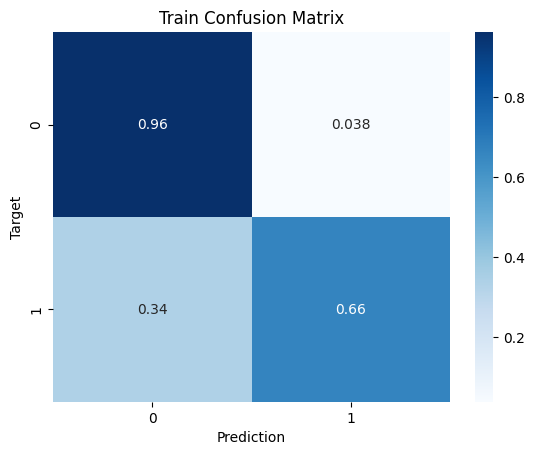

F1 score: 0.72%
Area under ROC score on Validation dataset: 0.91728%


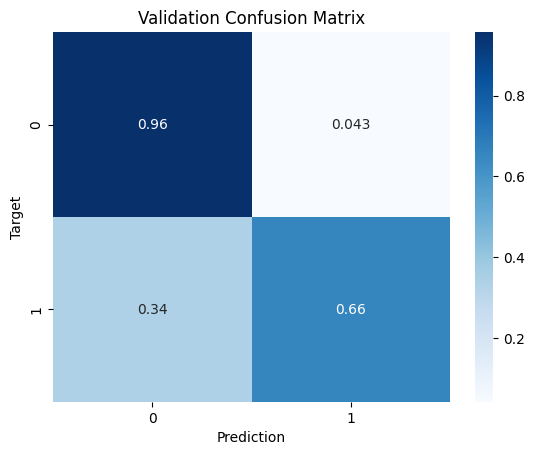

In [15]:
#Виведіть area under ROC для моделі на тренувальних і тестувальних даних.
train_preds = predict_and_plot(dt_random_search_best,X_train, train_targets, 'Train')
val_preds = predict_and_plot(dt_random_search_best,X_val, val_targets, 'Validation')

### висновок
модель краща ніж з GridSearch.
показники якості моделі на тернувальних і валідаційних даних майже однакові, що свідчить про гарно підібрані параметри для дерева

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

метрика вийшла не вища ніж в інших моделях, тому не робила сабміт в змаганнях.  Спробую внести деякі зміни і при кращому результаті зроблю сабміт